# Amazon Delivery Time Analysis

# Project: Can Probability Predict Whether an Amazon Delivery Will Be Late?

In this project, we use historical Amazon delivery data to explore how **probability and distributions** can answer real-world delivery questions.  

Starting with **Probability Mass Functions (PMF), Probability Density Functions (PDF), and Cumulative Distribution Functions (CDF)**, we will analyze delivery times, investigate how factors such as traffic and weather affect delivery performance, and estimate the likelihood of a delivery taking longer than a given threshold.  

We will then connect these statistical insights to **conditional probability and machine learning**, showing how probability provides the foundation for predicting future delivery outcomes.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.integrate import quad
# from KDEpy import FFTKDE
from scipy.interpolate import interp1d

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

## Data Loading and Inspection

In [2]:
df = pd.read_csv("data/amazon_delivery.csv")
df.head()

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys


In [3]:
# Check missing values
df.isna().sum()

Order_ID            0
Agent_Age           0
Agent_Rating       54
Store_Latitude      0
Store_Longitude     0
Drop_Latitude       0
Drop_Longitude      0
Order_Date          0
Order_Time          0
Pickup_Time         0
Weather            91
Traffic             0
Vehicle             0
Area                0
Delivery_Time       0
Category            0
dtype: int64

In [4]:
# Summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Agent_Age,43739.0,29.567137,5.815155,15.000000,25.000000,30.000000,35.000000,50.000000
Agent_Rating,43685.0,4.633780,0.334716,1.000000,4.500000,4.700000,4.900000,6.000000
Store_Latitude,43739.0,17.210960,7.764225,-30.902872,12.933298,18.551440,22.732225,30.914057
Store_Longitude,43739.0,70.661177,21.475005,-88.366217,73.170283,75.898497,78.045359,88.433452
Drop_Latitude,43739.0,17.459031,7.342950,0.010000,12.985996,18.633626,22.785049,31.054057
Drop_Longitude,43739.0,70.821842,21.153148,0.010000,73.280000,76.002574,78.104095,88.563452
Delivery_Time,43739.0,124.905645,51.915451,10.000000,90.000000,125.000000,160.000000,270.000000


In [5]:
# We only need Weather, Traffic, and Delivery_Time to be non-null for the
# analysis ahead.
analysis_columns = ["Weather", "Traffic", "Delivery_Time"]
df = df.dropna(subset=analysis_columns)
df.info()

<class 'pandas.DataFrame'>
Index: 43648 entries, 0 to 43738
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         43648 non-null  str    
 1   Agent_Age        43648 non-null  int64  
 2   Agent_Rating     43594 non-null  float64
 3   Store_Latitude   43648 non-null  float64
 4   Store_Longitude  43648 non-null  float64
 5   Drop_Latitude    43648 non-null  float64
 6   Drop_Longitude   43648 non-null  float64
 7   Order_Date       43648 non-null  str    
 8   Order_Time       43648 non-null  str    
 9   Pickup_Time      43648 non-null  str    
 10  Weather          43648 non-null  str    
 11  Traffic          43648 non-null  str    
 12  Vehicle          43648 non-null  str    
 13  Area             43648 non-null  str    
 14  Delivery_Time    43648 non-null  int64  
 15  Category         43648 non-null  str    
dtypes: float64(5), int64(2), str(9)
memory usage: 5.7 MB


In [6]:
df = df[['Weather', 'Traffic','Delivery_Time']]
df.head()

,Weather,Traffic,Delivery_Time
0,Sunny,High,120
1,Stormy,Jam,165
2,Sandstorms,Low,130
3,Sunny,Medium,105
4,Cloudy,High,150


## Probability Mass Function (PMF)

Before we can talk about delivery *time*, it helps to start with something simpler: a variable that can only take a small number of distinct values.

`Weather` and `Traffic` are both **discrete** - a delivery is recorded as "Sunny" or "Stormy", "High" or "Low", never something in between. For a discrete random variable, we can estimate its probability mass function (PMF) directly from observed frequencies:

P(X = x) = (number of deliveries where X = x) / (total number of deliveries)

This tells us the probability that a *randomly selected* delivery falls into each category - not a prediction about any single delivery.

In [7]:
# P.m.f of Weather
pmfWeather = ((df['Weather'].value_counts() / df['Weather']
    .value_counts().sum())
    .to_frame(name = "Probability (P(X=x))")
    .T.rename_axis("Weather (X)", axis=1))
pmfWeather

Weather (X),Fog,Stormy,Cloudy,Sandstorms,Windy,Sunny
Probability (P(X=x)),0.170455,0.168942,0.166972,0.165987,0.165483,0.162161


In [8]:
# P.m.f of Traffic
pmfTraffic = ((df['Traffic'].value_counts() / df['Traffic']
    .value_counts().sum())
    .to_frame(name = "Probability (P(X=x))")
    .T.rename_axis("Traffic (X)", axis=1))
pmfTraffic

Traffic (X),Low,Jam,Medium,High
Probability (P(X=x)),0.343635,0.314447,0.243493,0.098424


**What this tells us:** each table shows how delivery observations are distributed across categories of a single variable. For example, the PMF for `Traffic` tells us how likely a randomly chosen delivery is to have occurred under "Low", "Medium", "High", or "Jam" traffic conditions in this dataset.

A defining property of a PMF is that the probabilities of all possible outcomes must sum to exactly 1 - every delivery falls into exactly one category, so nothing is left over and nothing is double-counted. We check that below.

In [9]:
# Axiom of probabilities
print("Axioms of Probability: All probabilities sum upto one\n")
print(f"Sum of Weather Probabilities: {pmfWeather.sum(axis=1)} \n Sum of Traffic Probabilities: {pmfTraffic.sum(axis=1)}")

Axioms of Probability: All probabilities sum upto one

Sum of Weather Probabilities: Probability (P(X=x))    1.0
dtype: float64 
 Sum of Traffic Probabilities: Probability (P(X=x))    1.0
dtype: float64


## Probability Density Function (PDF)

`Delivery_Time` is different from `Weather` or `Traffic` - it's a **continuous** measurement (in this dataset, recorded in minutes). With a continuous variable, the probability of any *exact* value is essentially zero, so a PMF-style table doesn't make sense here.

Instead, we estimate a probability **density** function. A kernel density estimate (KDE) gives us a smooth curve approximating the underlying distribution of delivery times - but it's important to be precise about what this curve means:

- The **height** of the curve at a point is a density, not a probability.
- **Probability** corresponds to the **area under the curve** over some interval, e.g. P(120 < Delivery_Time < 140).
- The KDE is an *estimate* of the true underlying density, not the density itself.

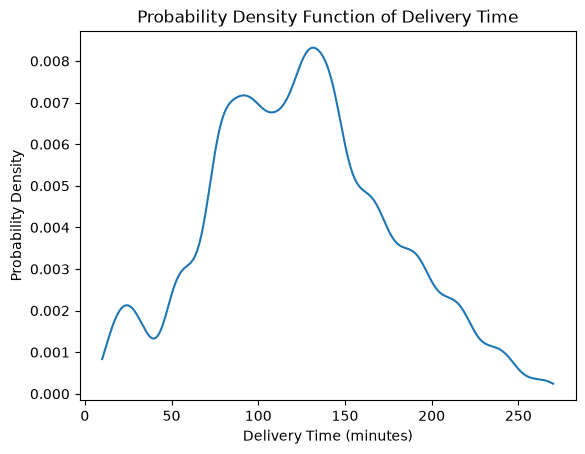

In [10]:
# Remove missing values
delivery_times = df["Delivery_Time"].dropna()

# Estimate the PDF
kde = gaussian_kde(delivery_times)

# Create x-values for the curve
x = np.linspace(
    delivery_times.min(),
    delivery_times.max(),
    500
)

# Get density values
y = kde(x)

# Plot the PDF
plt.plot(x, y)

plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Probability Density")
plt.title("Probability Density Function of Delivery Time")
plt.show()

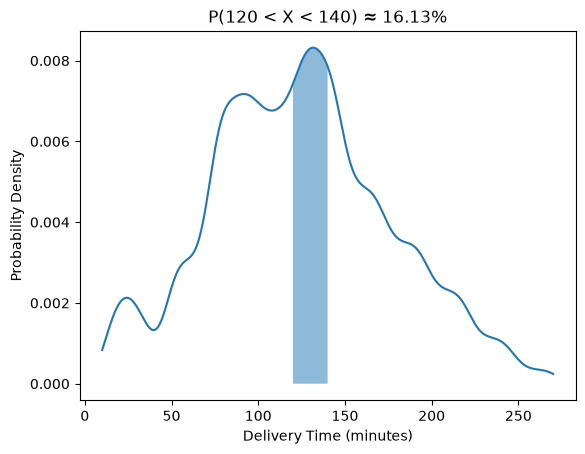

In [11]:
delivery_times = df["Delivery_Time"].dropna()

# Estimate PDF
kde = gaussian_kde(delivery_times)

# X values
x = np.linspace(delivery_times.min(), delivery_times.max(), 500)
y = kde(x)
upperBound = 140
lowerBound = 120

# Calculate probability
# Wrap it in a lambda so it only returns a single number (scalar)
probability, _ = quad(lambda val: kde(val)[0], lowerBound, upperBound)


# Plot PDF
plt.plot(x, y)

# Shade area between 30 and 45
x_fill = np.linspace(lowerBound, upperBound, 200)
y_fill = kde(x_fill)

plt.fill_between(x_fill, y_fill, alpha=0.5)

plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Probability Density")
plt.title(f"P({lowerBound} < X < {upperBound}) ≈ {probability:.2%}")

plt.show()

**What this tells us:** the shaded region shows the estimated probability that a randomly selected delivery takes between 120 and 140 minutes - computed as the area under the density curve over that interval, not as the height of the curve at any single point. This is the core distinction between a PMF and a PDF: a PMF gives probability directly at each discrete outcome, while a PDF only gives probability once you integrate over an interval.

In [12]:
#gausian kernel density

kde = gaussian_kde(delivery_times)

prob, error = quad(lambda val: kde(val)[0], delivery_times.min(), delivery_times.max())

print(f"Proability: {(prob * 100)}%")


Proability: 99.48437677716242%


In [ ]:
# 2. Extract discrete arrays from the library
x_grid, density = FFTKDE(kernel='epa', bw='silverman').fit(np.asarray(delivery_times)).evaluate(500)

# 3. CONVERT ARRAYS INTO A CONTINUOUS FUNCTION
# We use linear interpolation. 
# bounds_error=False and fill_value=0.0 ensure that if quad looks 
# outside the library's evaluated range, it safely gets a density of 0.
continuous_kde_func = interp1d(x_grid, density, kind='linear', 
                               bounds_error=False, fill_value=0.0)

# 4. Use quad to compute the continuous area under the curve
# Integrating from 0 to 10 (or -np.inf to np.inf)
raw_area, _ = quad(continuous_kde_func, x_grid.min(), x_grid.max())


print(f"Calculated Area via quad: {raw_area:.2f}")

## Cumulative Distribution Function (CDF)

The PDF told us about density in a narrow window. Often what we actually want to know is simpler: **what's the probability that delivery time is at most some value x?**

That's exactly what the cumulative distribution function (CDF) gives us:

F(x) = P(Delivery_Time ≤ x)

We'll compute the **empirical CDF** directly from the data - for any x, it's just the proportion of deliveries with a delivery time less than or equal to x. Unlike the PDF, we don't need to estimate anything here; the empirical CDF is just the data, sorted and accumulated.

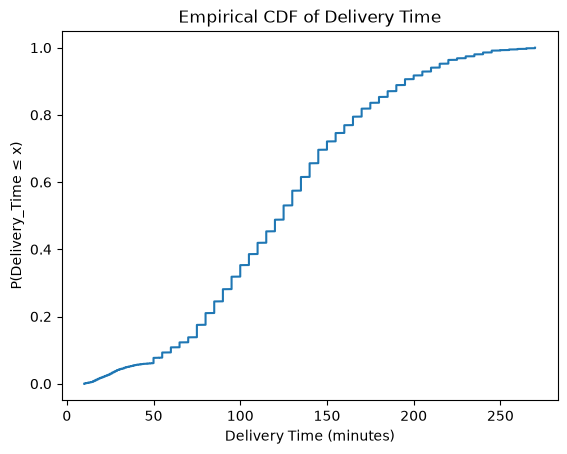

In [13]:
# Empirical CDF of delivery time
sorted_times = np.sort(df["Delivery_Time"])
cumulative_prob = np.arange(1, len(sorted_times) + 1) / len(sorted_times)

plt.plot(sorted_times, cumulative_prob)

plt.xlabel("Delivery Time (minutes)")
plt.ylabel("P(Delivery_Time ≤ x)")
plt.title("Empirical CDF of Delivery Time")
plt.show()

In [14]:
# Answer concrete questions using the empirical CDF
def empirical_cdf(x, data):
    return (data <= x).mean()

for threshold in [30, 45, 60]:
    prob = empirical_cdf(threshold, df["Delivery_Time"])
    print(f"P(Delivery_Time <= {threshold}) = {prob:.2%}")

prob_over_60 = 1 - empirical_cdf(60, df["Delivery_Time"])
print(f"P(Delivery_Time > 60) = {prob_over_60:.2%}")

P(Delivery_Time <= 30) = 4.24%
P(Delivery_Time <= 45) = 5.93%
P(Delivery_Time <= 60) = 10.81%
P(Delivery_Time > 60) = 89.19%


**What this tells us:** the CDF curve rises from 0 to 1 as delivery time increases - its height at any point x is the proportion of deliveries completed in x minutes or less. The steeper the curve, the more deliveries are concentrated around that range of times.

Note the numbers above are specific to this dataset - read them off the printed output rather than assuming round percentages. This also gives us a natural way to define what counts as a "late" delivery later on: we can choose a threshold and directly read off, from the data itself, what fraction of deliveries fall on each side of it.

## Conditional Distributions: Does Traffic Change the Picture?

So far we've treated all deliveries as one group. But we already know deliveries happen under different traffic conditions - does that matter for delivery time?

We can compare:

P(Delivery_Time ≤ x)

against:

P(Delivery_Time ≤ x | Traffic = t)

If knowing the traffic condition changes the distribution of delivery times, that's a meaningful signal - and it's exactly the kind of relationship a predictive model can learn to exploit later.

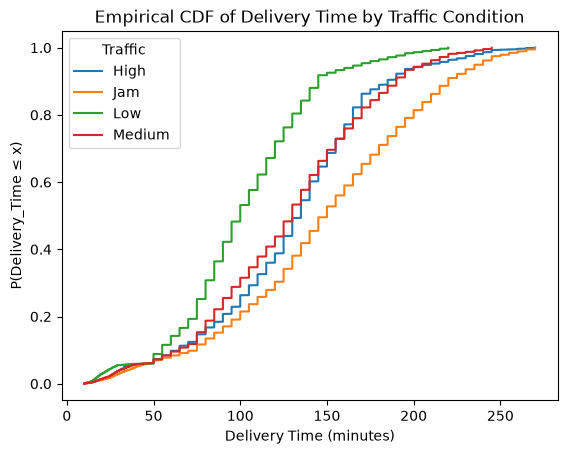

In [15]:
# Empirical CDF of delivery time, split by traffic condition
plt.figure()

for traffic_level in sorted(df["Traffic"].unique()):
    subset = df.loc[df["Traffic"] == traffic_level, "Delivery_Time"]
    sorted_subset = np.sort(subset)
    cumulative_prob = np.arange(1, len(sorted_subset) + 1) / len(sorted_subset)
    plt.plot(sorted_subset, cumulative_prob, label=traffic_level)

plt.xlabel("Delivery Time (minutes)")
plt.ylabel("P(Delivery_Time ≤ x)")
plt.title("Empirical CDF of Delivery Time by Traffic Condition")
plt.legend(title="Traffic")
plt.show()

In [16]:
# Conditional probabilities at a fixed threshold, compared to the unconditional case
threshold = 90

overall_prob = empirical_cdf(threshold, df["Delivery_Time"])
print(f"P(Delivery_Time <= {threshold}) = {overall_prob:.2%}  [unconditional]\n")

for traffic_level in sorted(df["Traffic"].unique()):
    subset = df.loc[df["Traffic"] == traffic_level, "Delivery_Time"]
    conditional_prob = empirical_cdf(threshold, subset)
    print(f"P(Delivery_Time <= {threshold} | Traffic = {traffic_level}) = {conditional_prob:.2%}")

P(Delivery_Time <= 90) = 28.12%  [unconditional]

P(Delivery_Time <= 90 | Traffic = High ) = 20.76%
P(Delivery_Time <= 90 | Traffic = Jam ) = 17.05%
P(Delivery_Time <= 90 | Traffic = Low ) = 42.22%
P(Delivery_Time <= 90 | Traffic = Medium ) = 25.50%


**What this tells us:** conditioning on traffic clearly shifts the distribution of delivery time. P(Delivery_Time ≤ 90) is 42.22% under Low traffic, but only 17.05% under Jam - a delivery under Low traffic is roughly 2.5x more likely to finish within 90 minutes than one under Jam conditions. Medium (25.50%) and High (20.76%) fall in between, and notably Medium slightly outperforms High - a reminder to read the data rather than assume it matches what the category names suggest.

This matches what the CDF plot already showed visually: the curves for each traffic condition are consistently ordered across the range of delivery times, not just at this one threshold. Knowing the traffic condition meaningfully changes what we can say about delivery time - which is exactly the kind of relationship a predictive model can learn to use.

## From Probability to Prediction: Defining "Late"

To predict whether a delivery is "late," we first need to define what late means - as a specific, checkable threshold on `Delivery_Time`.

In [17]:
# Recall Delivery_Time is roughly centered around its median (~125 minutes,
# from our earlier describe() output). A threshold near the median or slightly
# below it produces a meaningful split, rather than an overwhelmingly one-sided one.
print(df["Delivery_Time"].describe())

threshold_candidates = [60, 90, 120, 125]
print()
for t in threshold_candidates:
    prob_late = 1 - empirical_cdf(t, df["Delivery_Time"])
    print(f"Threshold {t} min -> P(Delivery_Time > {t}) = {prob_late:.2%} labeled 'Late'")

count    43648.000000
mean       124.914475
std         51.933163
min         10.000000
25%         90.000000
50%        125.000000
75%        160.000000
max        270.000000
Name: Delivery_Time, dtype: float64

Threshold 60 min -> P(Delivery_Time > 60) = 89.19% labeled 'Late'
Threshold 90 min -> P(Delivery_Time > 90) = 71.88% labeled 'Late'
Threshold 120 min -> P(Delivery_Time > 120) = 51.20% labeled 'Late'
Threshold 125 min -> P(Delivery_Time > 125) = 46.96% labeled 'Late'


We'll use **120 minutes** as our threshold: it sits close to the median delivery time, so it splits deliveries into two reasonably sized groups rather than an extreme majority/minority split.

In [18]:
threshold = 120
df["Late"] = (df["Delivery_Time"] > threshold).astype(int)
df[["Delivery_Time", "Late"]].head()

,Delivery_Time,Late
0,120,0
1,165,1
2,130,1
3,105,0
4,150,1


In [19]:
# P(Late) is itself just a PMF over a binary variable we constructed
pmfLate = ((df["Late"].value_counts(normalize=True))
    .to_frame(name="Probability (P(Late=x))")
    .rename(index={0: "On time", 1: "Late"}))
pmfLate

,Probability (P(Late=x))
Late,
Late,0.511959
On time,0.488041


**What this tells us:** `Late` is a new random variable we built from `Delivery_Time`, and just like `Weather` or `Traffic` earlier, it has its own PMF. At a 120-minute threshold, about 51.2% of deliveries are "Late" - close to a 50/50 split. This gives a model a meaningful task: a classifier that always guessed "on time" would only be right about 49% of the time, so there's real signal to learn here.

## Simple ML Model: Predicting P(Late | Features)

We've seen that `Traffic` shifts the conditional distribution of `Delivery_Time`. A natural next question: can we use variables like `Traffic` and `Weather` together to estimate the probability that a delivery will be late?

We'll use **logistic regression** - a model that directly estimates P(Late = 1 | features) as a probability between 0 and 1, rather than just producing a raw label. This is precisely why it fits naturally after everything we've done: it's estimating a conditional probability, the same object we were computing by hand in the previous section, just learned from multiple features at once instead of one at a time.

We deliberately keep the feature set small (`Traffic`, `Weather`) and skip anything derived from timestamps or IDs, since those wouldn't teach us anything about the *relationship* between conditions and lateness - the goal here is to see the ML model in action, not to maximize accuracy.

In [21]:
# Encode our two categorical features as dummy variables
features = pd.get_dummies(df[["Traffic", "Weather"]], drop_first=True)
target = df["Late"]

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((34918, 8), (8730, 8))

In [22]:
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:")
print(cm)

Accuracy: 71.90%
Confusion matrix:
[[2861 1387]
 [1066 3416]]


In [23]:
# The model doesn't just predict a label — it estimates P(Late = 1 | Traffic, Weather)
probabilities = model.predict_proba(X_test)[:, 1]

pd.DataFrame({
    "Traffic": df.loc[X_test.index, "Traffic"],
    "Weather": df.loc[X_test.index, "Weather"],
    "Actual_Late": y_test,
    "P(Late=1 | features)": probabilities
}).head(10)

,Traffic,Weather,Actual_Late,P(Late=1 | features)
25214,Jam,Cloudy,1,0.792697
23951,Medium,Fog,1,0.651775
39844,High,Cloudy,0,0.714647
38726,Medium,Cloudy,1,0.674740
27732,Jam,Sunny,0,0.422712
873,Low,Stormy,0,0.285420
25486,Low,Fog,0,0.344717
37004,Low,Windy,0,0.288074
24096,Medium,Sunny,0,0.284305
27614,Low,Cloudy,0,0.368306


**What this tells us:** logistic regression estimates the probability that a delivery is late given its traffic and weather conditions - it does not "learn the full distribution" of delivery times, only the conditional probability of this one binary outcome given these two features.

Using only `Traffic` and `Weather`, the model reaches 71.90% accuracy - clearly above the ~51.2% we'd get by always guessing "late" (the majority class from our earlier PMF of `Late`). That's a meaningful improvement from two categorical features alone, which supports what we already saw directly in the conditional CDF section: traffic condition genuinely shifts the distribution of delivery time, and the model has picked up on that same relationship.

The confusion matrix shows the model is reasonably balanced between error types (1387 false positives, 1066 false negatives out of 8730 test examples) rather than achieving its accuracy by defaulting to one class.

Look at the individual predicted probabilities above: a "Jam" + "Cloudy" delivery gets P(Late) ≈ 0.79, while a "Low" traffic delivery sits around 0.28-0.37 regardless of weather. This lines up with what we found by hand earlier - Low traffic was consistently associated with faster deliveries, Jam with slower ones - except now the model estimates that probability directly from two features combined, rather than us computing it for one category at a time.

It's also worth noting some individual predictions are wrong (e.g. row 2: predicted P(Late) ≈ 0.71 for a delivery that was actually on time). That's expected - `Traffic` and `Weather` are correlated with lateness, not perfectly determinative of it. A probability of 0.71 doesn't promise a late delivery; it means that, historically, deliveries with similar conditions were late about 71% of the time.